# nb_03 — Color-magnitude diagram

Goal (see `docs/SPEC_V01.md`, rough plan step 3): color-magnitude diagram (CMD), `g-r` vs `r`
by default — the color and magnitude bands are plain variables below, change them as you like.
Works on `dia_object_lc_10plus_with_stats` (nb_02's output).

**Resolves the spec's magnitude question.** `diaObject` itself has no usable per-band static
magnitude for a CMD: `{band}_psfFluxMean` is a difference-image statistic (near zero for a
non-varying source, useless as a brightness), and its science-image counterpart,
`{band}_scienceFluxMean`, turned out to exist but be too sparse to rely on (only ~20% of
objects have it populated in our subset). Going through the `Object` (coadd) table instead
would need a spatial crossmatch — slow, and ambiguous in crowded fields — so that's ruled out.

The right table is forced photometry on the science image at each diaObject's position, at
every visit — `ForcedSourceOnDiaObject`. It *is* reachable through LSDB: it's the nested
`diaObjectForcedSource` column already present in `dia_object_lc_10plus_with_stats`. Each row's
`psfFlux`/`psfMag` there is the calibrated science-image measurement, not a diff (`psfDiffFlux`
is the actual diff-image value, alongside it, for comparison). The median `psfMag` per band
across the forced-photometry rows covers ~99.7% of objects, vs. ~20% for the flat
`scienceFluxMean` columns — so that's what section 1 computes.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lsdb
from datapaths import Datapaths

dp = Datapaths()
subset_cat = lsdb.open_catalog(dp["dp2_subset"] / "dia_object_lc_10plus_with_stats")
print(subset_cat.npartitions, "partitions")
subset_cat


4 partitions


,dec,diaObjectId,nDiaSources,ra,tract,diaObjectForcedSource,diaSource,field,duration_days,median_cadence_gap_days,u_amp_p90p10,g_amp_p90p10,r_amp_p90p10,i_amp_p90p10,z_amp_p90p10,y_amp_p90p10
npartitions=4,,,,,,,,,,,,,,,,
"Order: 1, Pixel: 17",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ...",string[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 1, Pixel: 34",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 1, Pixel: 41",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 1, Pixel: 47",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


## 1. Per-band magnitude via forced photometry (`diaObjectForcedSource`)

Same `map_rows` pattern as nb_02, but this time on `diaObjectForcedSource` (nested, per-visit
forced photometry) instead of `diaSource` (nested, per-visit *detections* — biased toward
brighter/outburst epochs, since a detection has to clear a threshold). `append_columns=True`
merges the new columns straight back onto the lazy catalog, so there's no separate manual
column-merge step — the simplification flagged as a follow-up at the end of nb_02, used here
for the first time.

Median, not a flux-error-weighted mean: keeps the per-band aggregation consistent with nb_02's
robust-statistics style, at the cost of not being the statistically optimal combination — worth
revisiting if a workshop attendee needs tighter photometry than a demo CMD does.

Two quality cuts added on top of the plain median (missing from the first version of this
notebook — see section 3 for why extendedness isn't among them):
- **`MIN_FORCED_PER_BAND = 3`**: a band's median is only kept if at least 3 unflagged forced
  points went into it, `NaN` otherwise (previously any band with `>0` points was kept, which
  let a handful of noisy 1-2-point medians through and produced the implausible `g-r` outliers
  outside ±2 seen in the first version).
- **`FORCED_FLAG_COLS`**: excludes forced-source rows carrying any of `diaObjectForcedSource`'s
  own pixel/PSF-fit quality flags (saturated, cosmic ray, edge, interpolated, no-data pixels;
  a failed or invalid PSF flux fit) before computing the median.

Also computes `max_reliability` — the maximum of `diaSource.reliability` (DP2's per-detection
real/bogus ML score) across an object's light curve — for the reliability split in section 3.
`max`, not `median`: see that section for why.

**Environment bug found here:** calling `.write_catalog()` directly on the `map_rows(...,
append_columns=True)` result writes a collection whose auto-generated margin cache has the
wrong index name (`__index_level_0__` instead of `_healpix_29`), which then fails on reopen
with `ValueError: The margin catalog and the main catalog must have the same schema`. Routing
through `.compute()` + `lsdb.from_dataframe()` first (nb_01/nb_02's pattern) avoids it — so
`append_columns=True` only removes the manual column-assign step here, not the materialize
step, unlike what the "Next" cell in nb_02 anticipated.


### Heavy-calculation flag

`RUN_HEAVY_CALC` gates the `map_rows`/write/register step below; leave it `False` (the
default) to reuse the already-registered `dia_object_lc_10plus_with_mags` instead of
recomputing per-band forced-photometry medians for the whole subset, and go straight to the
CMD/color-color sections below. `band_mags` and its constants are still defined either way,
so the logic is there to read even when it doesn't run.

In [2]:
RUN_HEAVY_CALC = False

In [3]:
BANDS = "ugrizy"
MIN_FORCED_PER_BAND = 3

# Photometric quality flags on diaObjectForcedSource — exclude rows affected by any of these
# before taking the per-band median. Not exhaustive (diaSource has its own, separate per-epoch
# flags used by nb_02's stats), but these are the ones bearing directly on this section's
# forced-photometry magnitudes.
FORCED_FLAG_COLS = [
    "pixelFlags_bad", "pixelFlags_cr", "pixelFlags_crCenter", "pixelFlags_edge",
    "pixelFlags_interpolated", "pixelFlags_interpolatedCenter", "pixelFlags_nodata",
    "pixelFlags_saturated", "pixelFlags_saturatedCenter", "pixelFlags_suspect",
    "pixelFlags_suspectCenter", "psfFlux_flag", "invalidPsfFlag",
]


def band_mags(row):
    band = np.asarray(row["diaObjectForcedSource.band"])
    mag = np.asarray(row["diaObjectForcedSource.psfMag"], dtype=float)

    bad = np.zeros(len(band), dtype=bool)
    for c in FORCED_FLAG_COLS:
        bad |= np.asarray(row[f"diaObjectForcedSource.{c}"], dtype=bool)
    good = ~bad & np.isfinite(mag)

    out = {}
    for b in BANDS:
        band_mag = mag[good & (band == b)]
        out[f"{b}_mag_median"] = float(np.median(band_mag)) if len(band_mag) >= MIN_FORCED_PER_BAND else np.nan

    # DP2's per-detection real/bogus score, from the diaSource stream (not diaObjectForcedSource)
    # — see the markdown below for why this is `max`, not `median`, and why it's not a 0.9-style
    # real/bogus cut.
    reliability = np.asarray(row["diaSource.reliability"], dtype=float)
    out["max_reliability"] = float(np.nanmax(reliability)) if len(reliability) > 0 else np.nan
    return pd.Series(out)


with_mags_path = dp["dp2_subset"] / "dia_object_lc_10plus_with_mags"

if RUN_HEAVY_CALC:
    meta = {f"{b}_mag_median": "f8" for b in BANDS}
    meta["max_reliability"] = "f8"

    map_rows_columns = ["diaObjectForcedSource.band", "diaObjectForcedSource.psfMag", "diaSource.reliability"]
    map_rows_columns += [f"diaObjectForcedSource.{c}" for c in FORCED_FLAG_COLS]

    with_mags_cat = subset_cat.map_rows(
        band_mags,
        columns=map_rows_columns,
        meta=meta,
        append_columns=True,
    )

    # Route through compute() + from_dataframe() before writing (see the markdown above) instead
    # of calling with_mags_cat.write_catalog() directly.
    merged_df = with_mags_cat.compute()
    lsdb.from_dataframe(merged_df).write_catalog(with_mags_path, overwrite=True, create_thumbnail=False, progress_bar=False)
    print("wrote", with_mags_path)

    dp.register(
        name="dia_object_lc_10plus_with_mags",
        type="dp2_subset",
        fmt="hats-collection",
        src_path=str(with_mags_path / "collection.properties"),
        tags=["nb03", "dp2", "diaObject", "cmd", "forced-photometry"],
        inputs=["dia_object_lc_10plus_with_stats"],
        notes=(
            "dia_object_lc_10plus_with_stats plus {band}_mag_median (per band, median "
            "diaObjectForcedSource.psfMag, quality-flagged rows excluded, >=3 points required) "
            "and max_reliability (max diaSource.reliability) columns, from nb_03."
        ),
        overwrite_history=True,
    )
    dp.print_paths(name="dia_object_lc_10plus_with_mags")
else:
    print(f"RUN_HEAVY_CALC=False — skipping write/register; {with_mags_path} already up to date.")

RUN_HEAVY_CALC=False — skipping write/register; /home/shrra-ung/share/trieste/dia_object_lc_10plus_with_mags already up to date.


## 2. Color-magnitude diagram

Reopen the written collection to confirm the new columns persisted, then pull what's needed
for the CMD into a flat dataframe. `COLOR_BAND_BLUE` / `COLOR_BAND_RED` / `MAG_BAND` are plain
variables — change them for a different color or magnitude band.


In [4]:
cmd_cat = lsdb.open_catalog(dp["dp2_subset"] / "dia_object_lc_10plus_with_mags")
print(sorted(cmd_cat.columns))

COLOR_BAND_BLUE = "g"
COLOR_BAND_RED = "r"
MAG_BAND = "r"

mag_cols = sorted({f"{COLOR_BAND_BLUE}_mag_median", f"{COLOR_BAND_RED}_mag_median", f"{MAG_BAND}_mag_median"})
extra_cols = ["i_mag_median", "max_reliability"]  # not required for the plain CMD, kept for later sections

cmd_df = cmd_cat[["diaObjectId", "field", "r_amp_p90p10", *mag_cols, *extra_cols]].compute()
cmd_df = cmd_df.dropna(subset=mag_cols)
cmd_df["color"] = cmd_df[f"{COLOR_BAND_BLUE}_mag_median"] - cmd_df[f"{COLOR_BAND_RED}_mag_median"]
print(cmd_df.shape)
cmd_df[["color", f"{MAG_BAND}_mag_median"]].describe()


['dec', 'diaObjectForcedSource', 'diaObjectId', 'diaSource', 'duration_days', 'field', 'g_amp_p90p10', 'g_mag_median', 'i_amp_p90p10', 'i_mag_median', 'max_reliability', 'median_cadence_gap_days', 'nDiaSources', 'r_amp_p90p10', 'r_mag_median', 'ra', 'tract', 'u_amp_p90p10', 'u_mag_median', 'y_amp_p90p10', 'y_mag_median', 'z_amp_p90p10', 'z_mag_median']


Computing Catalog:   0%|          | 0/8 [00:00<?, ?it/s]

(6907, 8)


,color,r_mag_median
count,6907.0,6907.0
mean,0.904943,17.426979
std,0.270268,1.118325
min,-1.336241,15.208038
25%,0.730254,16.685354
50%,0.901073,17.300102
75%,1.085821,17.90848
max,2.246023,27.619526


### Plots

The single combined plot got crowded fast at ~7000 points, so this is split into two figures
instead, each answering one question:

- **One CMD panel per field**, colored by nb_02's r-band amplitude — does variability track a
  particular part of the CMD, and does that differ by field? (`plasma`, not `viridis` — under
  the alpha blending needed for this many points, viridis's yellow end washes out and stops
  reading as "high value".)
- **One CMD panel per amplitude bin** (`A < 0.2`, `0.2 ≤ A < 0.4`, `A ≥ 0.4`), colored by field
  — does splitting by amplitude reveal anything about which fields the more-variable objects
  come from?


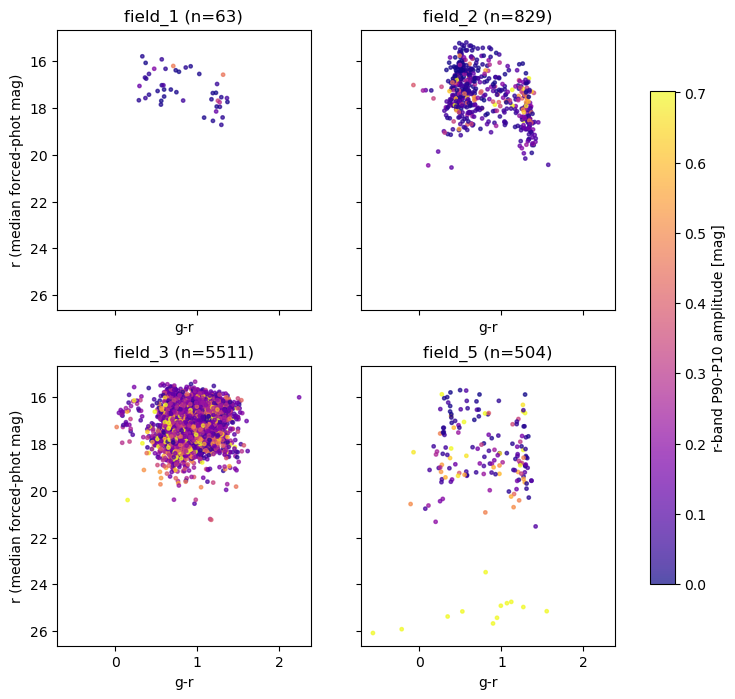

In [5]:
fields = sorted(cmd_df["field"].unique())
ncols = 2
nrows = int(np.ceil(len(fields) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(9, 4 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()

vmax = np.nanpercentile(cmd_df["r_amp_p90p10"], 95)
for ax, field_name in zip(axes, fields):
    group = cmd_df[cmd_df["field"] == field_name]
    sc = ax.scatter(
        group["color"],
        group[f"{MAG_BAND}_mag_median"],
        c=group["r_amp_p90p10"],
        cmap="plasma",
        s=6,
        alpha=0.7,
        vmin=0,
        vmax=vmax,
    )
    ax.set_title(f"{field_name} (n={len(group)})")
    ax.set_xlabel(f"{COLOR_BAND_BLUE}-{COLOR_BAND_RED}")

for ax in axes[len(fields):]:
    ax.set_visible(False)
for ax in axes[::ncols]:
    ax.set_ylabel(f"{MAG_BAND} (median forced-phot mag)")

axes[0].invert_yaxis()
fig.colorbar(sc, ax=axes[: len(fields)].tolist(), label="r-band P90-P10 amplitude [mag]", shrink=0.8)


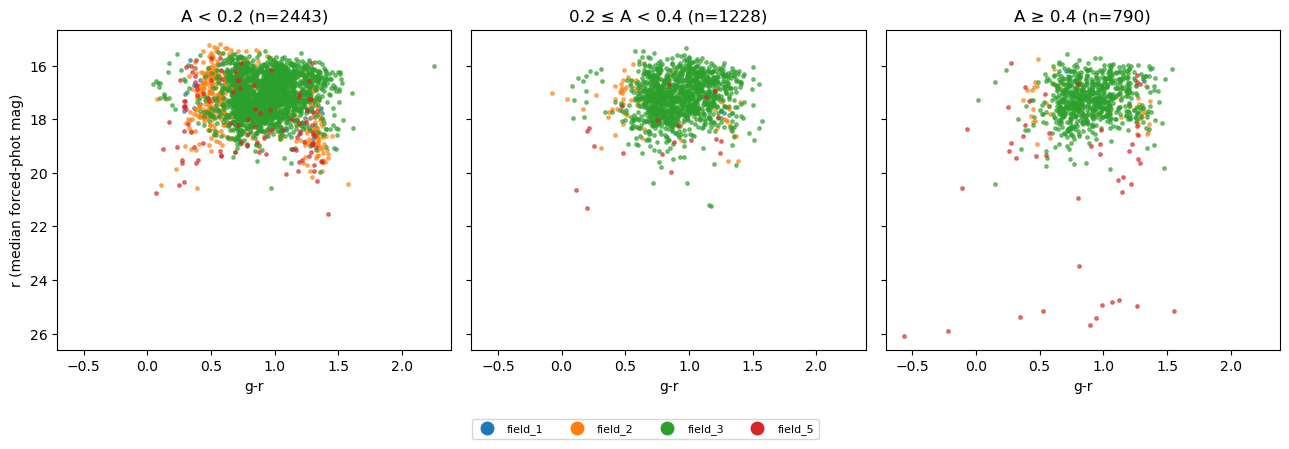

In [6]:
amp_bins = [(0, 0.2, "A < 0.2"), (0.2, 0.4, "0.2 ≤ A < 0.4"), (0.4, np.inf, "A ≥ 0.4")]
field_colors = {f: f"C{i}" for i, f in enumerate(fields)}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharex=True, sharey=True)

for ax, (lo, hi, label) in zip(axes, amp_bins):
    sub = cmd_df[(cmd_df["r_amp_p90p10"] >= lo) & (cmd_df["r_amp_p90p10"] < hi)]
    for field_name, group in sub.groupby("field"):
        ax.scatter(group["color"], group[f"{MAG_BAND}_mag_median"], s=6, alpha=0.6, color=field_colors[field_name])
    ax.set_title(f"{label} (n={len(sub)})")
    ax.set_xlabel(f"{COLOR_BAND_BLUE}-{COLOR_BAND_RED}")

axes[0].invert_yaxis()
axes[0].set_ylabel(f"{MAG_BAND} (median forced-phot mag)")

handles = [plt.Line2D([], [], marker="o", linestyle="", color=field_colors[f], label=f) for f in fields]
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.legend(handles=handles, loc="lower center", ncol=len(fields), bbox_to_anchor=(0.5, 0), fontsize=8, markerscale=1.5)


## 3. Quality flags: reliability, and the extendedness gap

The natural point-source/extended split — `extendedness`, typically from the coadd `Object`
table — isn't available here. It's not in `diaObject`'s flat columns, nor in the nested
`diaSource` or `diaObjectForcedSource` schemas of this catalog (checked directly against the
HATS schema, not just what happened to already be loaded). DP2's `diaSource` schema does
define an `extendedness` field, so this looks like something dropped when this particular HATS
catalog was built — not something that doesn't exist in DP2 at all. **Doing proper quality
filtering — extendedness among it — is going to need a data path other than this LSDB HATS
collection** (direct Butler/PPDB access, or a HATS catalog built with more columns retained);
this notebook can't do it as-is.

`diaSource.reliability` (DP2's per-detection real/bogus ML score, 0-1) is available, but it's
heavily skewed toward zero for this subset: the 99th percentile across all ~134k individual
detections is only ~0.09, and only ~1.2% of objects ever reach `reliability > 0.5` even at
their *best* epoch (`max`, computed in section 1 — `median` is even more degenerate, since most
epochs sit near zero for essentially every object). So it isn't usable as an absolute "> 0.9 =
real" cut the way it might be on a more mature classifier. Below it's used as a relative split
instead — top 10% of objects by `max_reliability` vs. the rest — which says more about
"unusually high-scoring within this specific sample" than "point source vs. galaxy" or "real
vs. bogus" in any calibrated sense.


top-10% max_reliability threshold: 0.0742


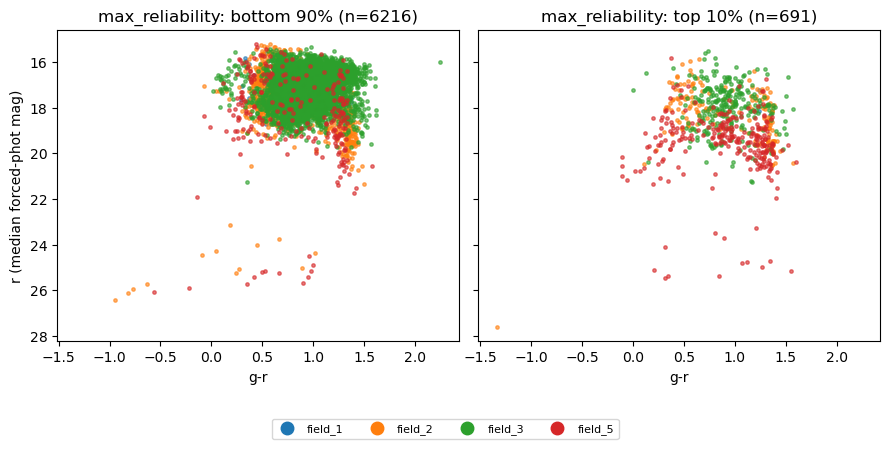

In [7]:
rel_threshold = np.nanpercentile(cmd_df["max_reliability"], 90)
print(f"top-10% max_reliability threshold: {rel_threshold:.4f}")

rel_bins = [(0, rel_threshold, "bottom 90%"), (rel_threshold, np.inf, "top 10%")]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), sharex=True, sharey=True)

for ax, (lo, hi, label) in zip(axes, rel_bins):
    sub = cmd_df[(cmd_df["max_reliability"] >= lo) & (cmd_df["max_reliability"] < hi)]
    for field_name, group in sub.groupby("field"):
        ax.scatter(group["color"], group[f"{MAG_BAND}_mag_median"], s=6, alpha=0.6, color=field_colors[field_name])
    ax.set_title(f"max_reliability: {label} (n={len(sub)})")
    ax.set_xlabel(f"{COLOR_BAND_BLUE}-{COLOR_BAND_RED}")

axes[0].invert_yaxis()
axes[0].set_ylabel(f"{MAG_BAND} (median forced-phot mag)")

fig.tight_layout(rect=[0, 0.1, 1, 1])
fig.legend(handles=handles, loc="lower center", ncol=len(fields), bbox_to_anchor=(0.5, 0), fontsize=8, markerscale=1.5)


## 4. Color-color diagram

`g-r` vs `r-i` by default (`COLOR2_BLUE`/`COLOR2_RED` — change for a different second color).
Needs `i_mag_median` too, on top of `g_mag_median`/`r_mag_median`, so this drops a few more
objects to `NaN`s than the plain CMD above.


Computing Catalog:   0%|          | 0/8 [00:00<?, ?it/s]

(6883, 7)


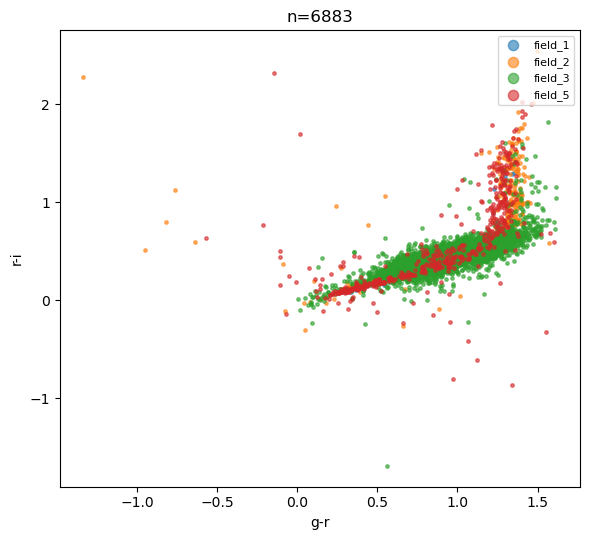

In [8]:
COLOR2_BLUE = "r"
COLOR2_RED = "i"

cc_cols = sorted({f"{COLOR_BAND_BLUE}_mag_median", f"{COLOR_BAND_RED}_mag_median", f"{COLOR2_BLUE}_mag_median", f"{COLOR2_RED}_mag_median"})
cc_df = cmd_cat[["diaObjectId", "field", *cc_cols]].compute()
cc_df = cc_df.dropna(subset=cc_cols)
cc_df["color1"] = cc_df[f"{COLOR_BAND_BLUE}_mag_median"] - cc_df[f"{COLOR_BAND_RED}_mag_median"]
cc_df["color2"] = cc_df[f"{COLOR2_BLUE}_mag_median"] - cc_df[f"{COLOR2_RED}_mag_median"]
print(cc_df.shape)

fig, ax = plt.subplots(figsize=(6, 5.5))
for field_name, group in cc_df.groupby("field"):
    ax.scatter(group["color1"], group["color2"], s=6, alpha=0.6, color=field_colors[field_name], label=field_name)
ax.set_xlabel(f"{COLOR_BAND_BLUE}-{COLOR_BAND_RED}")
ax.set_ylabel(f"{COLOR2_BLUE}-{COLOR2_RED}")
ax.set_title(f"n={len(cc_df)}")
ax.legend(markerscale=3, fontsize=8, loc="upper right")
fig.tight_layout()


Same, split per field — same layout as the per-field CMD in section 2.


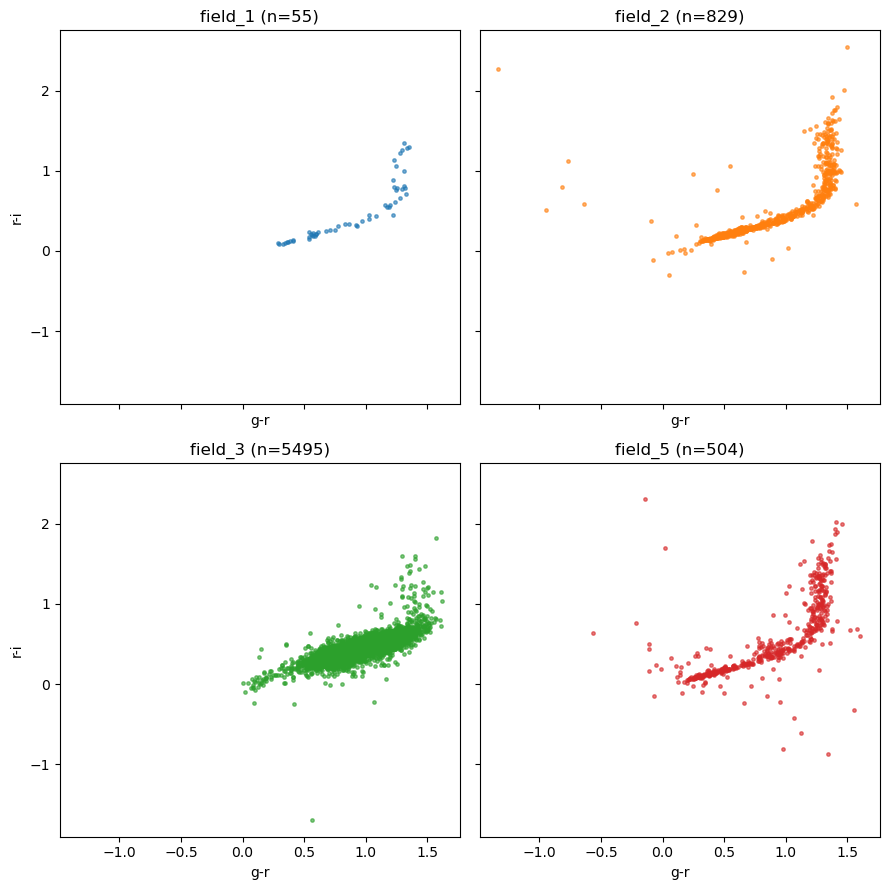

In [9]:
fields_cc = sorted(cc_df["field"].unique())
ncols = 2
nrows = int(np.ceil(len(fields_cc) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(9, 4.5 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()

for ax, field_name in zip(axes, fields_cc):
    group = cc_df[cc_df["field"] == field_name]
    ax.scatter(group["color1"], group["color2"], s=6, alpha=0.6, color=field_colors[field_name])
    ax.set_title(f"{field_name} (n={len(group)})")
    ax.set_xlabel(f"{COLOR_BAND_BLUE}-{COLOR_BAND_RED}")

for ax in axes[len(fields_cc):]:
    ax.set_visible(False)
for ax in axes[::ncols]:
    ax.set_ylabel(f"{COLOR2_BLUE}-{COLOR2_RED}")

fig.tight_layout()


## Next

`dia_object_lc_10plus_with_mags` is registered and carries the light curves, nb_02's stats,
and the new per-band median magnitudes (plus `max_reliability`) together.

Open questions carried forward, not resolved here:
- **Aggregation choice.** Median `psfMag` per band is simple and robust but not statistically
  optimal — a `psfFluxErr`-weighted mean would use the per-visit uncertainties properly.
- **Real quality filtering needs a different data path.** `extendedness` and any deeper
  point-source/extended or star/galaxy separation aren't reachable through this LSDB HATS
  collection (see section 3) — would need direct Butler/PPDB access, or a HATS catalog rebuilt
  with more columns retained.
- **`reliability`'s calibration.** DP2's `diaSource.reliability` is heavily skewed near zero in
  this subset (section 3); the top-10% split used here is relative, not an absolute real/bogus
  cut — worth revisiting once/if a better-calibrated version is available.
- **`field_4` has no g-band coverage at all** (checked: 0/14 objects have any g-band
  `diaObjectForcedSource` rows — only `r`/`i` were observed there), so it drops out of any
  `g`-involving plot here. Not a bug — a real per-field band-coverage gap — but worth checking
  per-band coverage on nb_01's depth map before picking a field for a band-specific demo.
